# Defense-Basket — a quantitative teardown 🔬
### Event study on 20 geopolitical shocks · excess-over-SPY · plain + HAC *t* · a placebo randomization null · costs · ETF cross-check · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_rally%3F: Busted](https://img.shields.io/badge/Reliable_rally%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "defense rallies on war" fuses: a couple of **memorable** rallies from the **average** behaviour of the basket relative to the market — and we confront both with the **sample size**. The decisive object is not the point estimate (it's actually *negative*, against the lore) but its **power**: with ~20 lifetime shocks, the event-window excess is statistically indistinguishable from drawing the same number of random dates.

> ⚠️ **Data + basket note.** "Defense" = an explicit **4-name equal-weight basket** (LMT, RTX, NOC, GD), excess measured vs **SPY**; we cross-check the **ITA** sector ETF (lists from 2006). Real data: yfinance daily adjusted closes, 1995→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from defense_basket import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
EVENTS = data.shock_dates()
print("real defense cache present:", HAVE_REAL, "| shock dates:", len(EVENTS))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-04', 'end': '2026-06-18', 'days': 7917, 'years': 31.5, 'n_events': 20, 'w5': (5, 20, -0.14, 45, 0.08, 52, -0.19, -0.19, 0.661), 'w21': (21, 20, -1.32, 50, 0.33, 54, -1.22, -1.13, 0.938), 'w63': (63, 20, -2.25, 30, 1.06, 55, -1.33, -1.2, 0.961), 'net': [(5, -0.14, -0.24), (21, -1.32, -1.42), (63, -2.25, -2.35)], 'robust': [(5, -0.14, -0.19, 0.661), (10, -0.67, -0.77, 0.878), (21, -1.32, -1.22, 0.938), (42, -1.58, -1.01, 0.927), (63, -2.25, -1.33, 0.961)], 'ita': (14, -0.87, 43, 0.19, -1.32, 0.862), 'syn': [(0.0, 20, 0.84, -0.53, 0.61, 0.151), (0.06, 20, 6.76, -0.16, 4.63, 0.0)], 'events': [('1998-08-20', 2.54), ('1998-12-16', -12.92), ('1999-03-24', 0.14), ('2001-09-17', 4.33), ('2001-10-08', -8.52), ('2003-03-20', -1.64), ('2008-08-08', 3.11), ('2011-03-21', -3.98), ('2014-03-03', -1.49), ('2014-09-23', 1.14), ('2015-09-30', 1.06), ('2017-04-07', 2.6), ('2018-04-13', -8.03), ('2019-09-16', -3.17), ('2020-01-03', -1.91), ('2021-08-16', -2.59), ('2022-02-24', 6.24), ('2023-10-09', 3.04), ('2024-04-15', 0.44), ('2024-10-01', -6.87)]}


real defense cache present: True | shock dates: 20


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Month-after excess over SPY **-1.32%** (base **+0.33%**); plain **t = -1.22**, HAC **t = -1.13**, placebo **p = 0.94** — *negative* and insignificant; ITA cross-check **t = -1.32**. |
| **Tradability** | `MIRAGE` | Long-basket / short-SPY trade: gross **-1.32%**, net **-1.42%** per trade; **20 events in 32y**. No positive edge to charge costs against — it loses money. |
| **Reliable rally?** | `BUSTED` | Beats-the-market rate **50%** at 1mo (base **54%**); the spread runs **+6.2% (Ukraine)** to **−12.9% (Desert Fox)**. Vivid-event + base-rate illusion. |

> 💡 In plain words: the war trade doesn't just fail to beat the market — in this sample it *trails* it, and the trailing is inside its own error bar. Strip the two famous rallies and 20 events leave nothing a random draw can't reproduce.

## 1 · The claim, steelmanned

Let $r^{D}_t$ be the equal-weight defense-basket daily return and $r^{M}_t$ the market (SPY) return; the **excess** is $x_t = r^{D}_t - r^{M}_t$. For shock date $\tau$ the **event-window excess** is $X_\tau(W) = \prod_{s=\tau+1}^{\tau+W}(1+x_s) - 1$ (one-day entry lag, hold $W$ days).

- **H₁ (the rally is real & positive).** $\mathbb{E}[X_\tau(W)] > 0$ and large — defense out-earns the market after a shock.
- **H₂ (it's deployable).** The excess is reliable and frequent enough, net of costs, to run as a long/short trade.
- **H₃ ("reliably rallies").** The post-shock behaviour reflects a shock-specific edge, not selective memory of a few vivid wins.

We find **H₁ rejected in sign** ($\bar X < 0$, $|t| < 2$), **H₂ rejected** (negative, ~20 events / 31y), **H₃ rejected** (beats-market rate ≈ a coin, the average is dragged down by losers as big as the famous winners). The reflex is true exactly where it's untestable (a couple of anecdotes) and false where it would pay (the average).

## 2 · So what? — what rides on each answer

The whole teardown is one estimate and its standard error:

$$\bar X = \frac1k\sum_{\tau} X_\tau(W),\qquad t = \frac{\bar X}{s_X/\sqrt{k}}.$$

With $k = 20$, $s_X/\sqrt{k}$ is large: a one- or two-point $\bar X$ drowns in its own SE whichever way it points. A raw **win-rate** is the wrong lens — defense carries a mild positive beta drift vs SPY *unconditionally*, so the right comparison is the **excess over that base rate**, not the sign. And because the daily in-window observations overlap and autocorrelate, we also report a **Newey-West (HAC)** *t* on the pooled daily excess. Finally, the honest small-sample instrument is a **randomization (placebo) test**: resample $k$ random entry dates and ask how often chance matches the shocks. That number decides the Signal axis.

## 3 · How we'd know — the protocol

- **Universe.** Equal-weight daily return of LMT/RTX/NOC/GD; excess vs SPY (yfinance adjusted closes, 1995-01-04→2026-06-18, 7,917 days). ITA ETF as a shorter-window cross-check.
- **Treatment.** **20** hardcoded war/invasion/rearmament headline dates, chosen ex-ante on the *headline* (listed in `data.py`; sourced in references).
- **Event window.** Cumulative excess over $W\in\{5,21,63\}$ trading days, entering the close **1 day after** the shock (no look-ahead); drop events whose window overruns the tape.
- **Null #1 (t / HAC-t).** Event-window excess vs zero (plain one-sample *t*); pooled in-window daily excess vs zero with a Bartlett-kernel **Newey-West** SE.
- **Null #2 (placebo).** 20,000 draws of $k$ random valid entry dates; $p = \Pr[\text{random-draw mean} \ge \text{shock mean}]$ — the small-sample workhorse.
- **Costs.** 1-day lag + a 10-bps all-in round-trip on the long-basket / short-SPY pair.
- **Positive control.** A deterministic frame where the basket is $\beta\cdot$SPY + noise (zero true excess by construction) with **20 shocks injected** and a **known** window edge: the engine must recover a planted edge **and** must NOT manufacture significance when the true edge is zero.

> **What would make us say "mirage":** a negative or insignificant $\bar X$, a beats-market rate near the base rate, and a placebo $p$ far from the tails. That is exactly what we get.

## 4 · The teardown

### 4a · The point estimates — negative, small, growing with the window

Event-window excess with its $\pm$ standard error, against the unconditional base rate (diamonds). Negative at every horizon, and *more* negative the longer you hold.

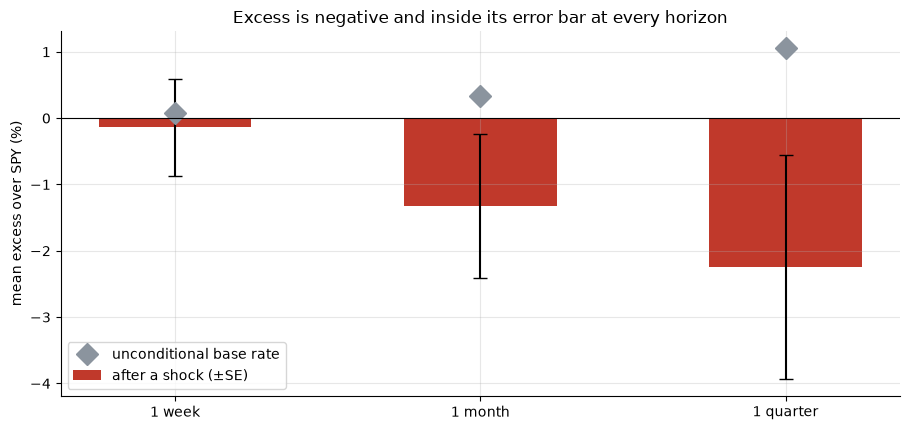

plain t by window: {'5d': -0.19, '21d': -1.22, '63d': -1.33}


In [2]:
wins = [5, 21, 63]
if HAVE_REAL:
    cm, bm, ts = [], [], []
    for w in wins:
        s = st.summarize(F, EVENTS, window=w); cm.append(s['cond_mean']); bm.append(s['base_mean']); ts.append(s['t'])
    ses = [(lambda e: e.std(ddof=1)/np.sqrt(len(e)))(st.event_excess(F, EVENTS, window=w)) for w in wins]
else:
    cm = [R['w5'][2]/100, R['w21'][2]/100, R['w63'][2]/100]
    bm = [R['w5'][4]/100, R['w21'][4]/100, R['w63'][4]/100]
    ts = [R['w5'][6], R['w21'][6], R['w63'][6]]; ses = [0.0075, 0.011, 0.017]
x = np.arange(len(wins))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=RED, width=.5, label='after a shock (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels(['1 week', '1 month', '1 quarter']); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean excess over SPY (%)')
ax.set_title('Excess is negative and inside its error bar at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('plain t by window:', {f'{w}d': round(t,2) for w,t in zip(wins,ts)})

> 💡 In plain words: at one month the basket runs **-1.32%** *vs* a base **+0.33%** — a ~1.6-point shortfall at **t = -1.22** (not significant). At a quarter it's **-2.25%** (**t = -1.33**). H₁ is **rejected in sign**: not the positive edge the lore promises, but a small negative number you can't distinguish from zero.

### 4b · The decisive test — a placebo null sized to the event count

Draw 20 *random* entry dates 20,000 times; the histogram is the null distribution of the month-after mean excess. The shocks are the red line; the *p*-value is the right-tail mass (the share of random draws that do *as well or better*).

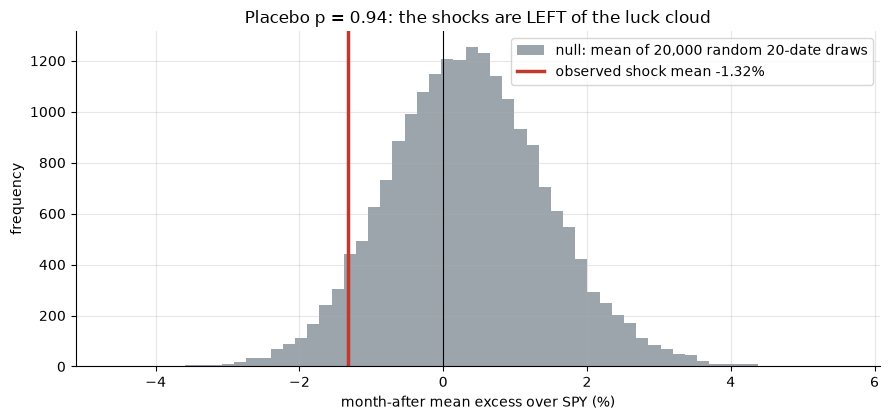

P[random 20-date draw >= shocks] = 0.938  (a positive edge would push this <0.05)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(F, EVENTS, window=21); obs = pl['shock_mean']; pval = pl['p_value']
    one = 1.0 + F['excess'].values; n=len(one); w=21; lag=1
    valid = np.array([one[s:s+w].prod()-1 for s in range(lag, n-w) if not np.isnan(one[s:s+w]).any()])
    rng = np.random.default_rng(394)
    draws = np.array([valid[rng.integers(0,len(valid),size=len(EVENTS))].mean() for _ in range(20000)])
else:
    obs = R['w21'][2]/100; pval = R['w21'][8]
    rng = np.random.default_rng(394); draws = rng.normal(R['w21'][4]/100, 0.012, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: mean of {len(draws):,} random 20-date draws')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed shock mean {obs*100:.2f}%')
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('month-after mean excess over SPY (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the shocks are LEFT of the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random 20-date draw >= shocks] = {pval:.3f}  (a positive edge would push this <0.05)')

> 💡 In plain words: **94%** of random 20-date samples *beat* the war shocks. A real edge would push the red line into the far **right** tail; instead it sits **left** of the cloud's centre. This is the crux — not a weak positive, but a point estimate a random dartboard reproduces (and improves on) nine times in ten. H₃ rejected.

### 4c · Robustness, ETF cross-check, and cost — nothing rescues it

Vary the holding window, swap to the ITA sector ETF, and apply a round-trip cost. The excess is negative at *every* window, ITA agrees, and 10 bps barely moves a multi-week hold (cost is **not** the binding constraint — there's simply no edge).

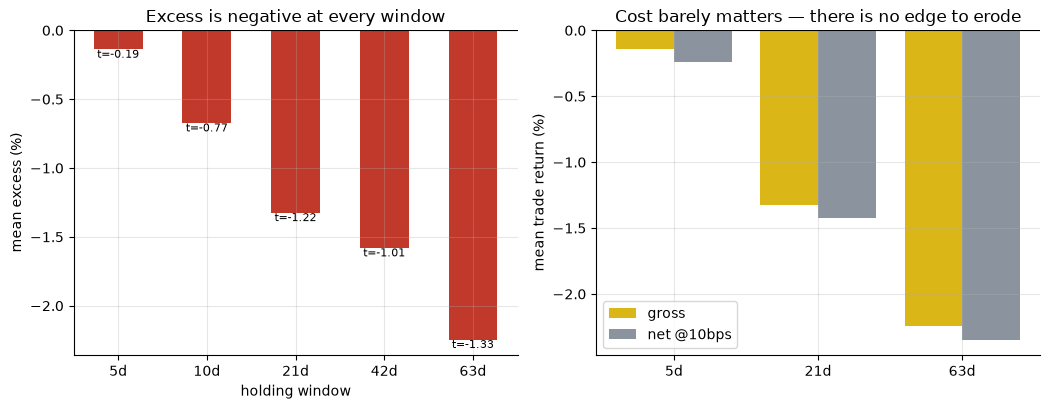

ITA cross-check (1mo): n=14 cond=-0.87% win=43% base=0.19% t=-1.32 p=0.862


In [4]:
if HAVE_REAL:
    rob = []
    for w in (5,10,21,42,63):
        s = st.summarize(F, EVENTS, window=w); rob.append((w, s['cond_mean']*100, s['t'], s['p_placebo']))
    F2 = F.copy(); F2['etf_excess'] = F2['etf'] - F2['mkt']
    ev_ita = pd.DatetimeIndex([d for d in EVENTS if d >= pd.Timestamp('2006-05-05')])
    si = st.summarize(F2, ev_ita, window=21, col='etf_excess')
    ita = (si['n'], si['cond_mean']*100, si['cond_win']*100, si['base_mean']*100, si['t'], si['p_placebo'])
    netr = [(w,)+(lambda c:(c['gross_mean']*100,c['net_mean']*100))(st.net_of_costs(F, EVENTS, window=w, cost_bps=10.0)) for w in (5,21,63)]
else:
    rob = R['robust']; ita = R['ita']; netr = [(w,g,nn) for (w,g,nn) in R['net']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
ws = [r[0] for r in rob]; cms = [r[1] for r in rob]
a1.bar([f'{w}d' for w in ws], cms, color=RED, width=.55)
a1.axhline(0, c='k', lw=.8)
for i,(c,r) in enumerate(zip(cms,rob)): a1.annotate(f't={r[2]:.2f}',(i,c),ha='center',va='top' if c<0 else 'bottom', fontsize=8)
a1.set_title('Excess is negative at every window'); a1.set_xlabel('holding window'); a1.set_ylabel('mean excess (%)')
ms = [r[0] for r in netr]; g = [r[1] for r in netr]; nv = [r[2] for r in netr]; xx=np.arange(len(ms))
a2.bar(xx-.2,g,.4,color=AMBER,label='gross'); a2.bar(xx+.2,nv,.4,color=GREY,label='net @10bps')
a2.axhline(0, c='k', lw=.8)
a2.set_xticks(xx); a2.set_xticklabels([f'{w}d' for w in ms]); a2.set_ylabel('mean trade return (%)')
a2.set_title('Cost barely matters — there is no edge to erode'); a2.legend()
plt.tight_layout(); plt.show()
print(f'ITA cross-check (1mo): n={ita[0]} cond={ita[1]:.2f}% win={ita[2]:.0f}% base={ita[3]:.2f}% t={ita[4]:.2f} p={ita[5]:.3f}')

> 💡 In plain words: the single-name basket and the ITA ETF (**t = -1.32**, placebo p = 0.86) tell the *same* story — a small negative excess, no significance. There is no window and no instrument at which the war trade turns positive, and a 10-bps round-trip shaves a tenth of a point off a months-long hold. **The constraint is the absence of an edge, not the cost of trading it.**

### 4d · Faithful-engine & power control — we know the truth here

On a deterministic frame where the basket is $\beta\cdot$SPY + idiosyncratic noise (so the true excess is **zero** by construction) with **20 shocks injected**: with **zero** planted edge the test must stay below t=2 (20 events can't fake significance); with a **+6%/month** planted edge it must light up. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large edges.

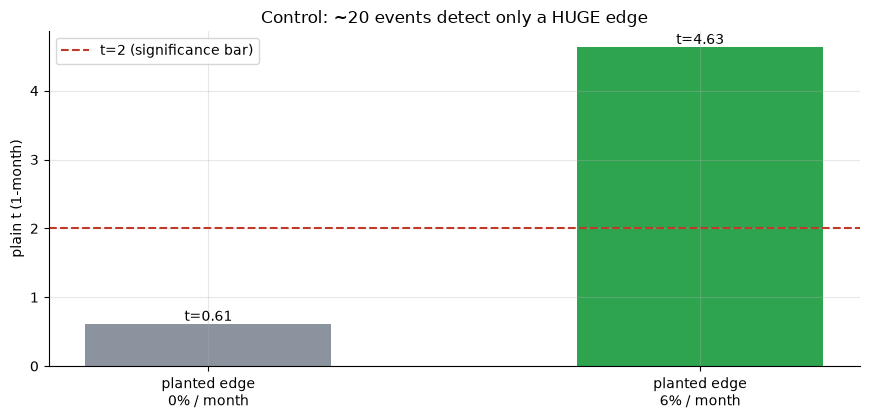

planted +0%/mo: detected=20 cond=0.84% base=-0.53% t=0.61 p=0.151
planted +6%/mo: detected=20 cond=6.76% base=-0.16% t=4.63 p=0.000


In [5]:
res = []
for edge in (0.0, 0.06):
    syn, evs = data.synthetic_defense(n_events=20, edge_window=edge, seed=394, window=21)
    s = st.summarize(syn, evs, window=21)
    res.append((edge, s['n'], s['cond_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 (significance bar)')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('plain t (1-month)'); ax.set_title('Control: ~20 events detect only a HUGE edge'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: detected={k} cond={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real edge the control sits at **t = 0.61** (below 2 — no false positive); only a **+6%/month** edge — enormous — reaches **t = 4.63**. So the machinery is honest, and the real-tape *t* of **-1.22** is exactly what an *absent* edge looks like through a 20-event keyhole. The sample size is half the verdict; the negative sign is the other half.

## 5 · The verdict

- **Signal `NONE`** — month-after excess **-1.32%** at plain **t = -1.22** / HAC **t = -1.13** / placebo **p = 0.94**; ITA cross-check **t = -1.32**; negative at every window. Not REAL, not even WEAK — the point estimate has the **wrong sign** and is indistinguishable from zero.
- **Tradability `MIRAGE`** — long-basket / short-SPY loses **-1.42%** per trade net (gross **-1.32%**); costs are negligible (no edge to erode); **20 trades / 32y**. Un-allocatable and unprofitable.
- **Reliable rally? `BUSTED`** — beats-market rate **50%** vs base **54%**; spread **+6.2% (Ukraine)** to **−12.9% (Desert Fox)**. A vivid-event + base-rate illusion: the wins you remember are cancelled by the losses you don't.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* month-after excess have to be for a $k$-event study to detect it at t=2? At $k=20$ you'd need a large positive excess; the real signal is **negative**, sitting below the axis — there is no edge to size, only a loss to avoid.

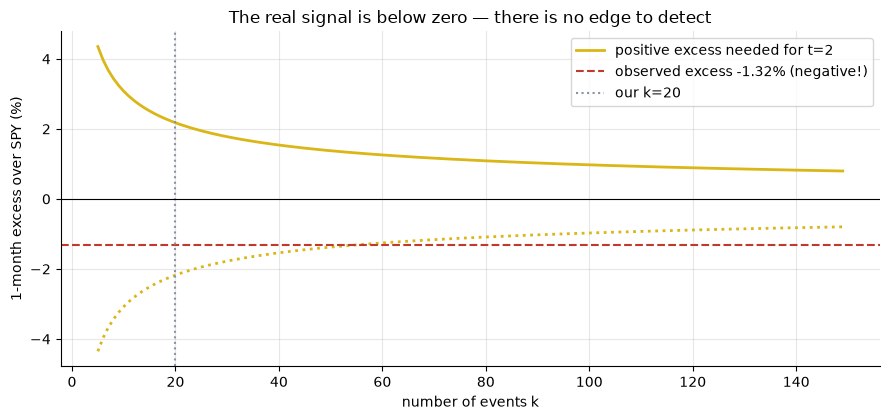

at k=20 you would need ~+2.2% excess for t=2; observed is -1.32% (wrong sign)


In [6]:
if HAVE_REAL:
    ee = st.event_excess(F, EVENTS, window=21); sd = ee.std(ddof=1)
    obs_excess = R['w21'][2]/100
else:
    sd = 0.048; obs_excess = R['w21'][2]/100
ks = np.arange(5, 150)
min_detectable = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='positive excess needed for t=2')
ax.plot(ks, -min_detectable*100, c=AMBER, lw=2, ls=':')
ax.axhline(obs_excess*100, c=RED, ls='--', label=f'observed excess {obs_excess*100:.2f}% (negative!)')
ax.axvline(R['n_events'], c=GREY, ls=':', label=f"our k={R['n_events']}")
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('number of events k'); ax.set_ylabel('1-month excess over SPY (%)')
ax.set_title('The real signal is below zero — there is no edge to detect'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_events'])
print(f'at k={R["n_events"]} you would need ~+{need*100:.1f}% excess for t=2; observed is {obs_excess*100:.2f}% (wrong sign)')

> 💡 In plain words: the amber band is the **minimum detectable excess** (positive or negative); the red line — what we actually observe — sits *below zero*, well inside the band. Even granting the lore a real edge, you'd need many times more shocks than history will ever supply to certify it — and the point estimate isn't even pointing the right way. **There is no sizing, no window, no cost assumption that turns a couple of remembered rallies into a strategy. The rarity that makes the trade feel obvious is exactly what makes it untestable, and the average is what makes it a loser.**

## 7 · Going further

- **Anticipation horizon.** The negative post-headline excess is consistent with the shock being priced *before/on* the event. A clean fork: scan the run-up window ($\tau-W$ to $\tau$) for the rally the reflex is actually (mis)remembering.
- **Wider universe / true sector cap-weight.** Replace the 4-name basket with the full ITA holdings or an XAR-style equal-weight; the dispersion and base rate shift, the power problem does not.
- **The fundamental long game.** The *budget* thesis lives at a multi-**year** horizon (appropriations → orders → earnings), a different and more defensible claim than the same-month headline rally tested here.

*The reproducible core is offline and deterministic; the basket and shock list are explicit and editable. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*